# Routing Scenario Analysis

- physical scenario
  - scenarios
    - fwd / bwd
    - hazard / no hazard
    - ablation scenario
  - plot
    - routes by month for physical scenario
    - elite_cost vs. elite_length for physical scenario

In [1]:
from pathlib import Path
from tqdm.auto import tqdm

import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import cartopy 

from load_tuning_results import (
    load_results_raw,
    load_result_for_key,
    add_derived_features,
    filter_suspicious_routes,
)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
gdf = gpd.read_parquet("../results/results_prelim.geoparquet")
gdf = add_derived_features(gdf)
gdf

,hyper_population_size,hyper_random_seed,hyper_selection_acceptance_rate_warmup,hyper_mutation_width_fraction_warmup,hyper_mutation_displacement_fraction_warmup,hyper_generations,hyper_offspring_size,hyper_crossover_rounds,hyper_selection_quantile,hyper_selection_acceptance_rate,...,elite_cost_relative,geometry,forcing_scenario_name,forcing_currents_path,forcing_waves_path,forcing_winds_path,hyper_num_individuals,journey_duration,seed_cost,elite_speed_og_mps_average
filename,,,,,,,,,,,,,,,,,,,,,
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,0.880062,"LINESTRING (-11 50, -12.82735 50.10402, -14.69...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,11 days 10:10:42,5.926383e+12,6.446294
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,0.880062,"LINESTRING (-11 50, -12.82735 50.10402, -14.69...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,11 days 10:10:42,5.926383e+12,6.446294
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,0.017000,"LINESTRING (-11 50, -12.31098 50.04275, -13.47...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,0.017000,"LINESTRING (-11 50, -12.31098 50.04275, -13.47...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0002:seed3030206584,128,3030206584,0.3,0.99,0.25,2,4,1,0.10,0.25,...,0.056787,"LINESTRING (-80.5 30, -79.65597 30.6855, -78.8...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,13 days 17:00:51,7.524805e+13,5.326478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
result:3997:seed3352588423,64,3352588423,0.3,0.99,0.25,1,4,1,0.25,0.25,...,0.995504,"LINESTRING (-80.5 30, -79.82039 30.53534, -79....",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,64,17 days 03:16:03,1.424118e+13,4.115572
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,0.975562,"LINESTRING (-11 50, -12.8399 50.12425, -14.687...",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,128,11 days 10:10:42,6.351398e+12,6.186218
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,0.975562,"LINESTRING (-11 50, -12.8399 50.12425, -14.687...",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,128,11 days 10:10:42,6.351398e+12,6.186218


In [4]:
gdf = filter_suspicious_routes(gdf)

0.35% suspicious routes


In [5]:
gdf.columns

Index(['hyper_population_size', 'hyper_random_seed',
       'hyper_selection_acceptance_rate_warmup',
       'hyper_mutation_width_fraction_warmup',
       'hyper_mutation_displacement_fraction_warmup', 'hyper_generations',
       'hyper_offspring_size', 'hyper_crossover_rounds',
       'hyper_selection_quantile', 'hyper_selection_acceptance_rate',
       'hyper_mutation_width_fraction', 'hyper_mutation_displacement_fraction',
       'hyper_mutation_iterations', 'hyper_crossover_strategy',
       'hyper_hazard_penalty_multiplier', 'hyper_num_elites',
       'hyper_gd_iterations', 'hyper_learning_rate_time',
       'hyper_learning_rate_space', 'hyper_time_increment',
       'hyper_distance_increment', 'hyper_enable_adaptation',
       'hyper_target_relative_improvement', 'hyper_adaptation_scale_W',
       'hyper_adaptation_scale_D', 'hyper_W_min', 'hyper_W_max', 'hyper_D_min',
       'hyper_D_max', 'hyper_num_workers', 'hyper_executor_type',
       'journey_name', 'journey_lon_waypoints

## Cost Distributions

In [6]:
def plot_cost_distributions(
    gdf: gpd.GeoDataFrame = None,
    forcing_scenario_name: str = "baseline",
    hyper_hazard_penalty_multiplier: float = 0.0,
    relabs: str = "absolute",
):
    _gdf = gdf.where(
        (gdf.hyper_hazard_penalty_multiplier == hyper_hazard_penalty_multiplier)
        & (gdf.forcing_scenario_name == forcing_scenario_name)
    ).dropna(how="all")
    _gdf = _gdf.assign(
        time_start=pd.to_datetime(_gdf["journey_time_start"]).dt.strftime("%Y-%m")
    )

    g = sns.catplot(
        data=_gdf,
        x=f"elite_cost_{relabs}",
        row="journey_name",
        col="journey_speed_knots",
        hue="time_start",
        kind="violin",
        height=3,
        aspect=2,
        inner="quartile",
        legend=True,
        margin_titles=True,
    )
    g.set_titles(col_template=f"{{col_name}} knots, {forcing_scenario_name}", row_template="{row_name}")
    g.fig.savefig(f"../figures/02_cost_distribution_{relabs}_scen-{forcing_scenario_name}_hazardmult-{hyper_hazard_penalty_multiplier}.png", dpi=200)
    g.fig.savefig(f"../figures/02_cost_distribution_{relabs}_scen-{forcing_scenario_name}_hazardmult-{hyper_hazard_penalty_multiplier}.pdf", dpi=200)
    return g.fig

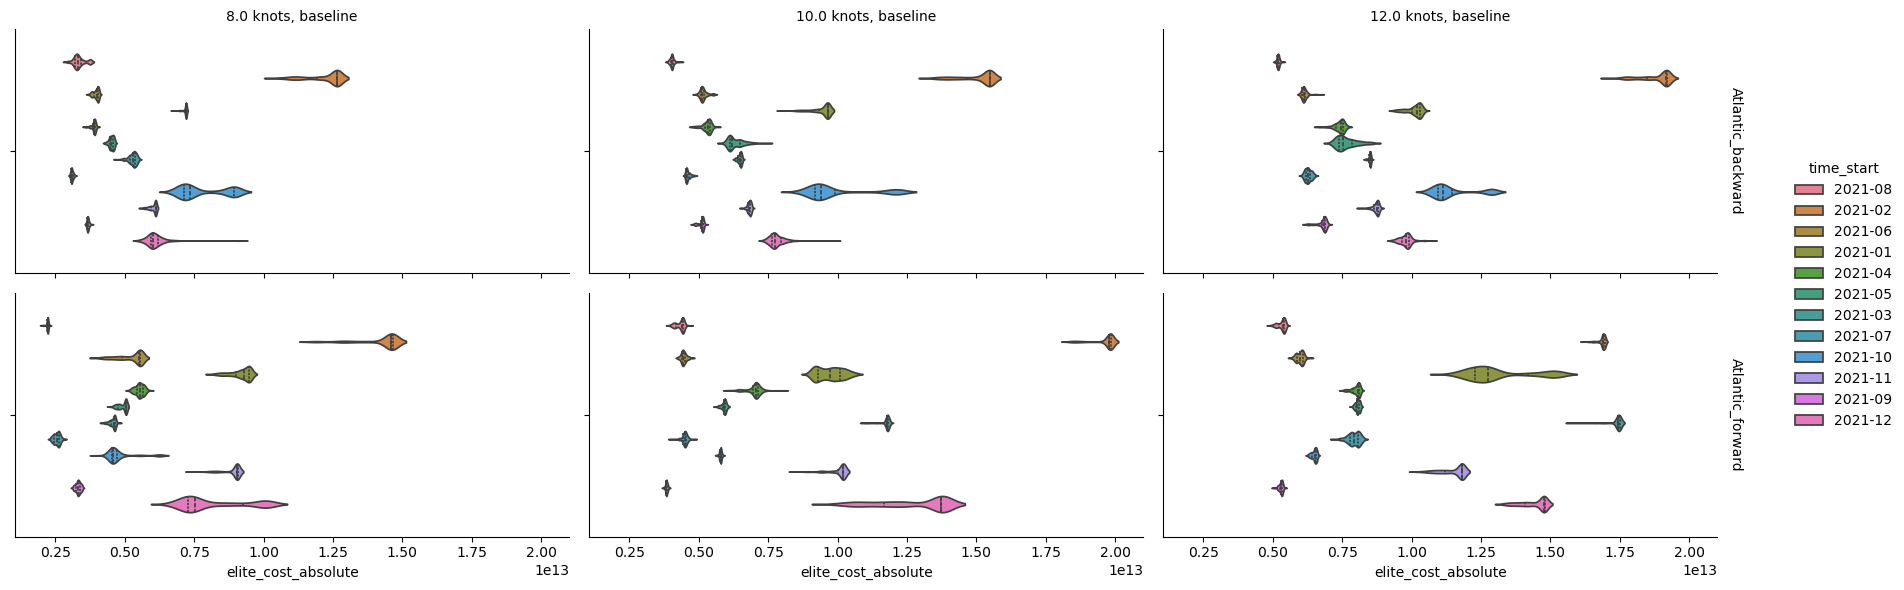

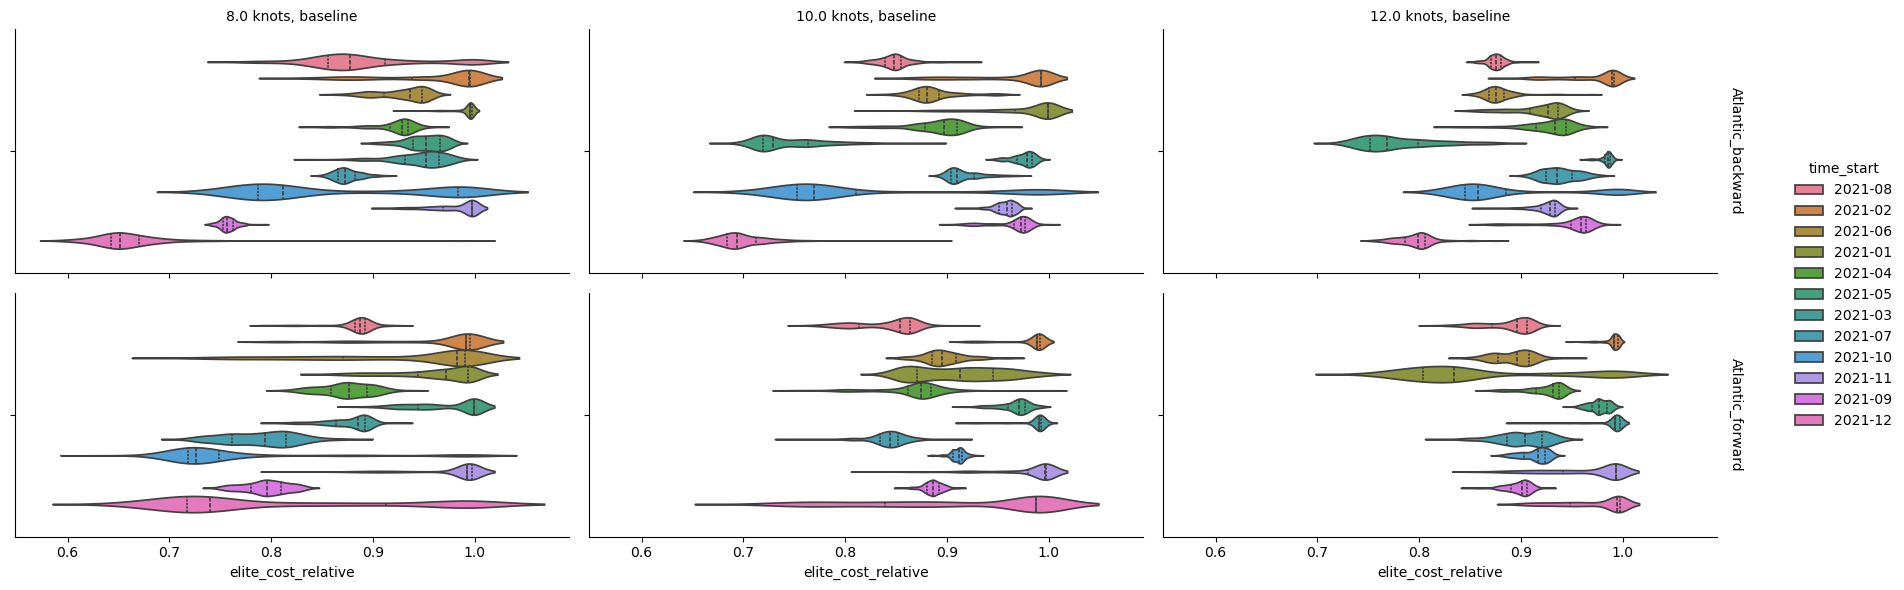

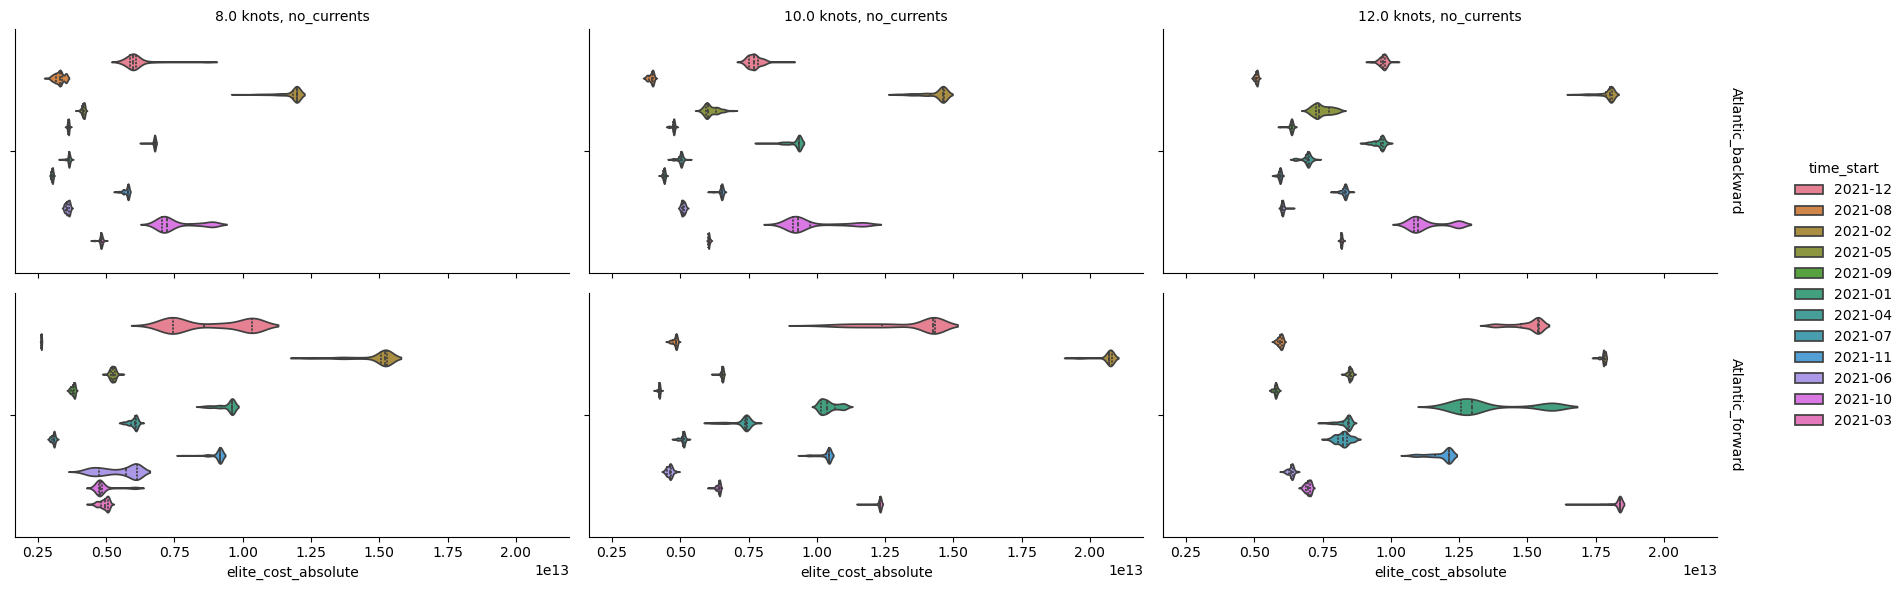

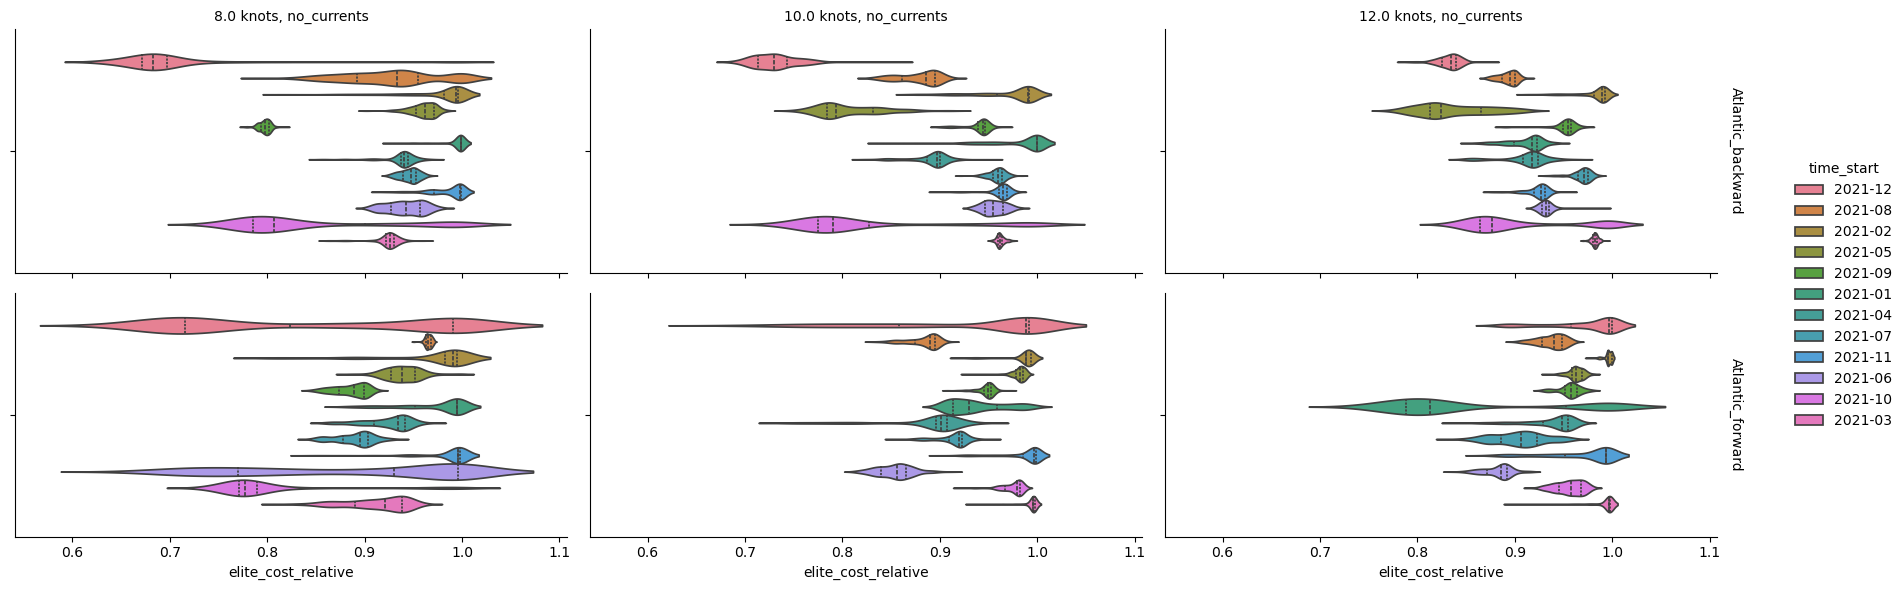

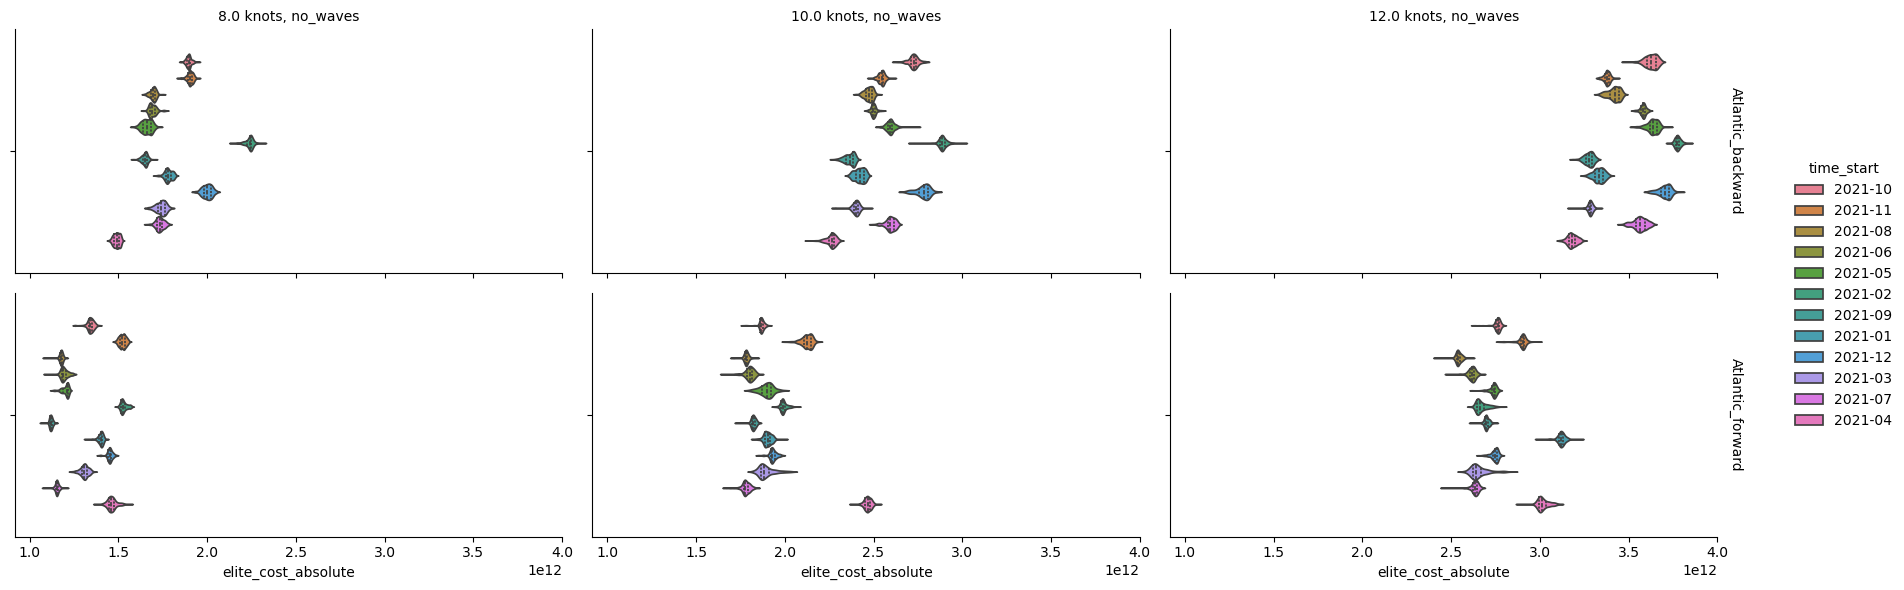

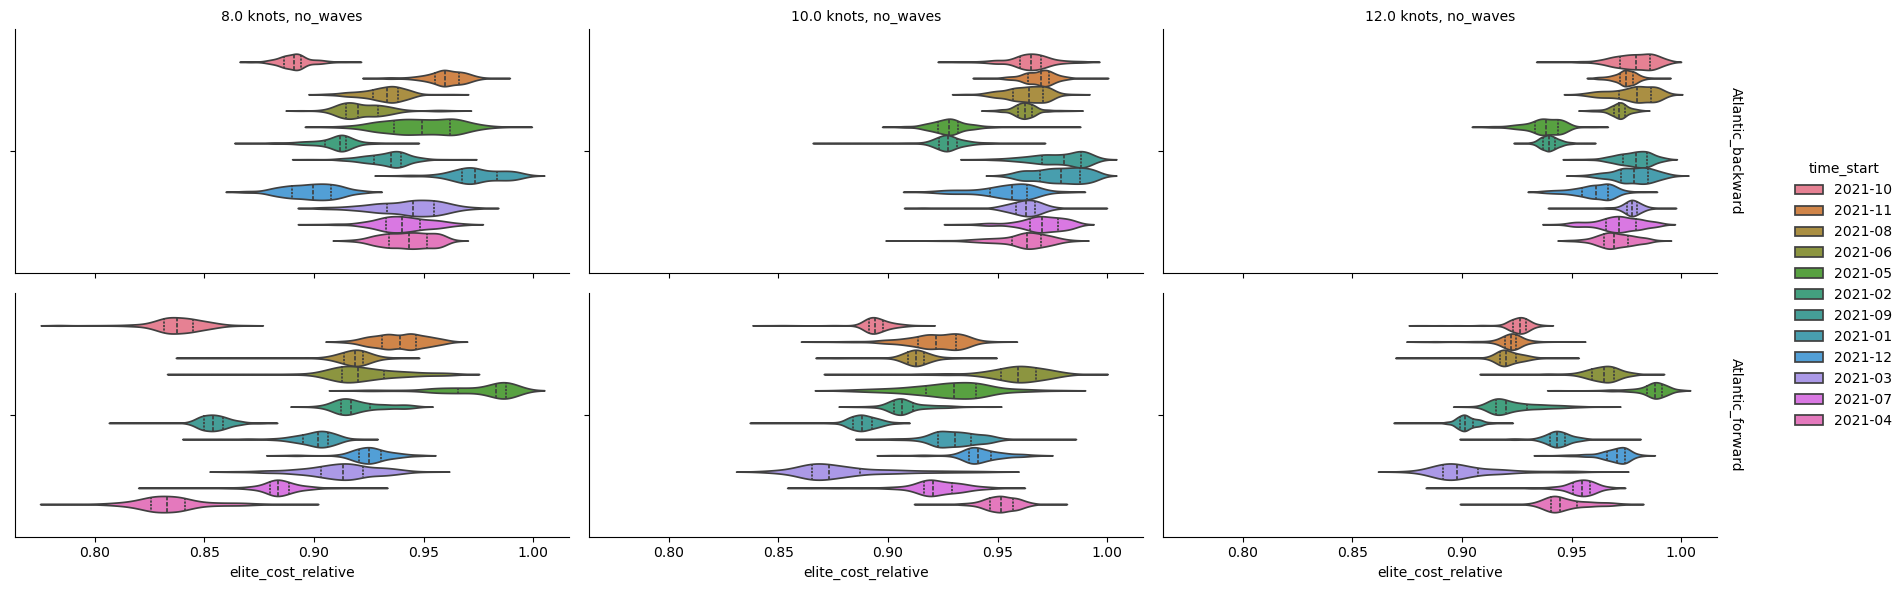

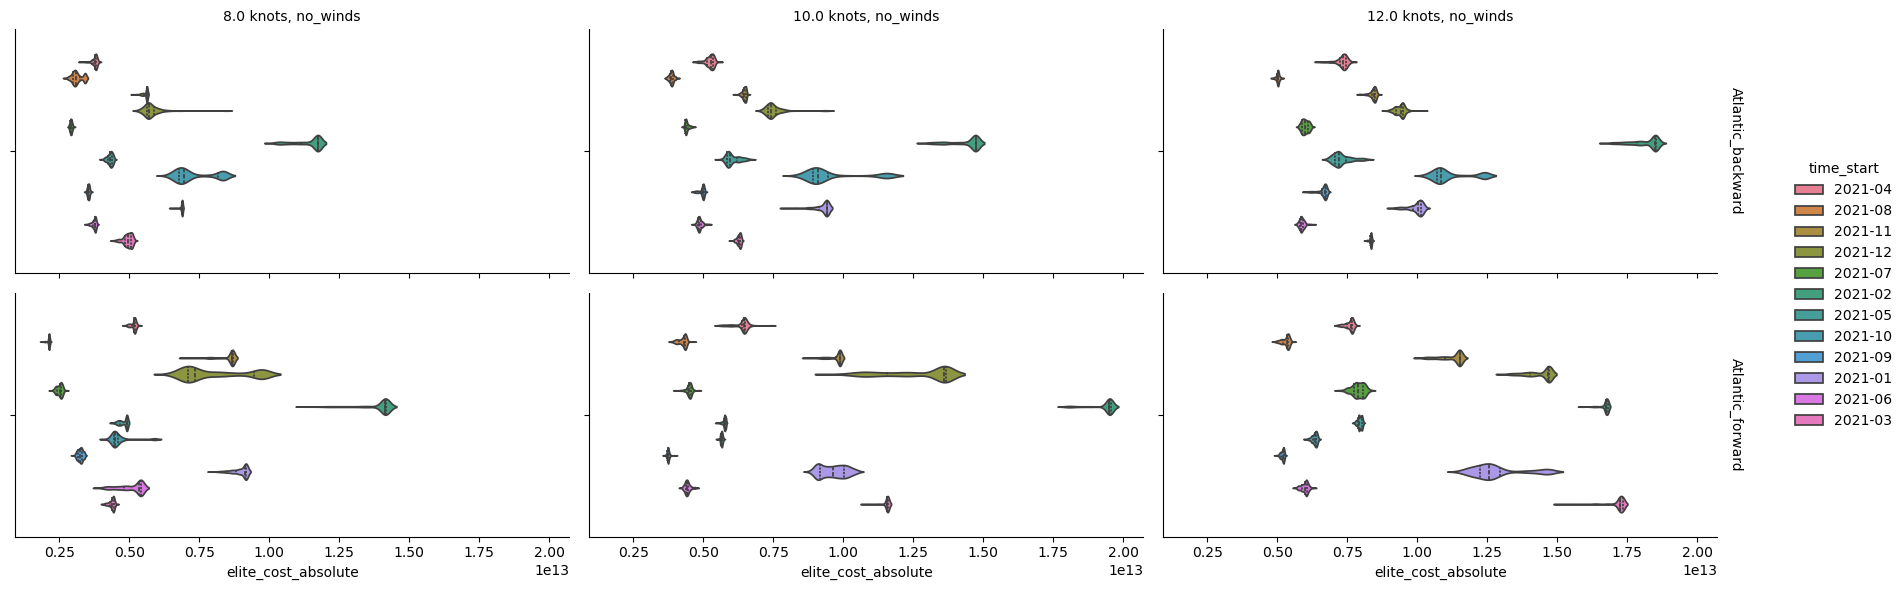

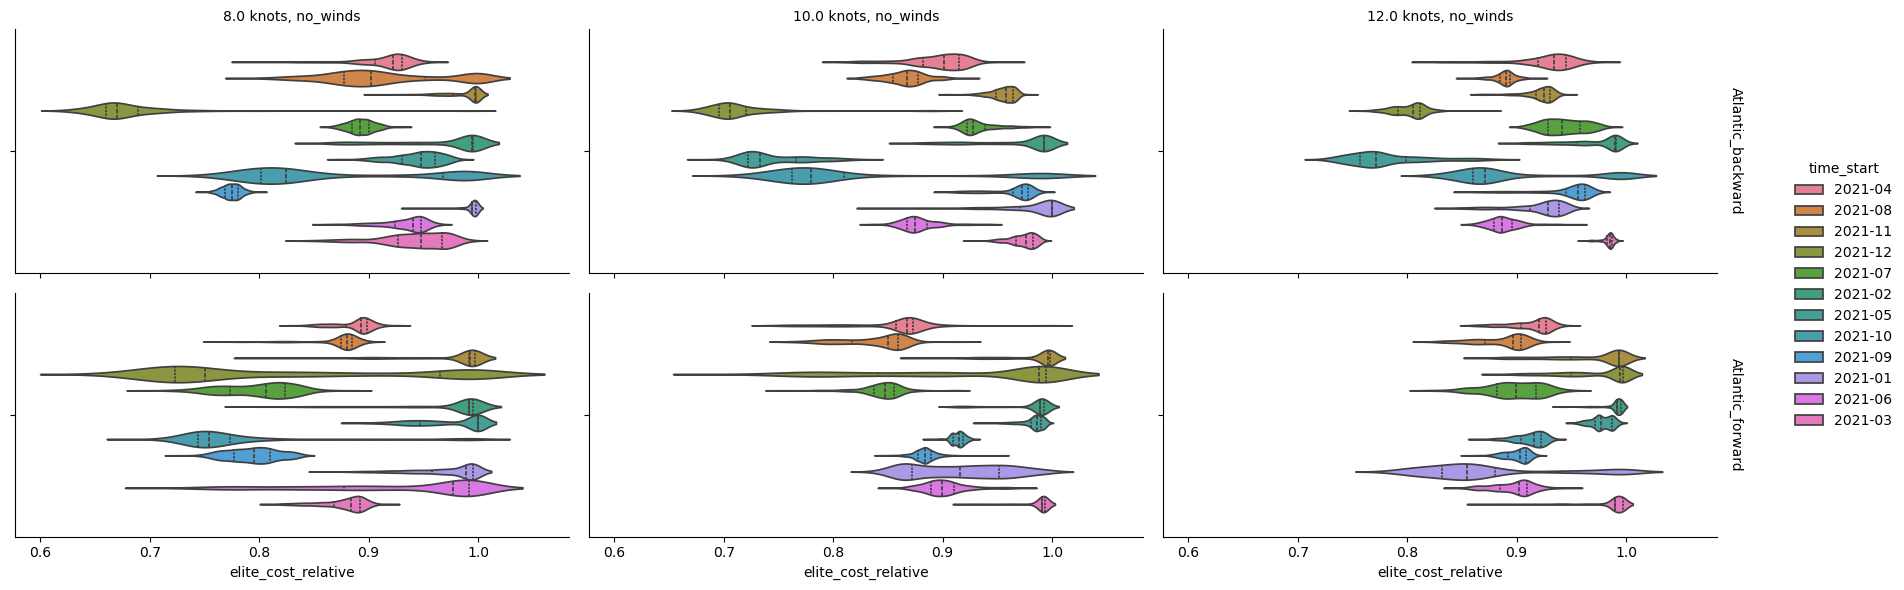

In [7]:
for fsn in gdf.forcing_scenario_name.unique():
    for relabs in ["absolute", "relative"]:
        plot_cost_distributions(gdf=gdf, forcing_scenario_name=fsn, hyper_hazard_penalty_multiplier=0, relabs=relabs);

## Best routes per month

In [8]:
def plot_routes_per_month(
    gdf: gpd.GeoDataFrame = None,
    forcing_scenario_name: str = "baseline",
    hyper_hazard_penalty_multiplier: float = 0,
):
    _gdf = gdf.where(
        (gdf.hyper_hazard_penalty_multiplier == hyper_hazard_penalty_multiplier)
        & (gdf.forcing_scenario_name == forcing_scenario_name)
    ).dropna(how="all")
    _gdf = _gdf.assign(
        time_start=pd.to_datetime(_gdf["journey_time_start"]).dt.strftime("%Y-%m")
    )
    cols_scenario = ['journey_name', 'journey_speed_knots', 'journey_time_start']
    _gdf_best = _gdf.sort_values(by="elite_cost_relative").groupby(cols_scenario).first().reset_index()
    
    fig, ax = plt.subplots(
        3, 2, 
        subplot_kw={
            "projection": cartopy.crs.Stereographic(
                central_latitude=_gdf.geometry.centroid.y.mean(), 
                central_longitude=_gdf.geometry.centroid.x.mean(),
            ),
        },
        sharex=True, sharey=True,
        figsize=(8, 7),
    )
    for n, jsk in enumerate(sorted(_gdf.journey_speed_knots.unique())):
        for m, jn in enumerate(_gdf.journey_name.unique()):
            _ax = ax[n, m]
            _gdf_best.where(
                (_gdf_best.journey_name == jn) & (_gdf_best.journey_speed_knots == jsk)
            ).plot(
                column="journey_time_start",
                # cmap="viridis",
                legend=False,
                ax=_ax,
                transform=cartopy.crs.PlateCarree()
            )
            hdl, _ = _ax.get_legend_handles_labels()
            _ax.coastlines()
            _ax.gridlines()
            _ax.set_title(f"{jn:s}: {jsk:.1f} knots")
    fig.suptitle(f"Best routes per month, {forcing_scenario_name}")
    fig.tight_layout()
    fig.savefig(f"../figures/02_best_routes_scen-{forcing_scenario_name}.png", dpi=200)
    fig.savefig(f"../figures/02_best_routes_scen-{forcing_scenario_name}.pdf", dpi=200)
    return fig

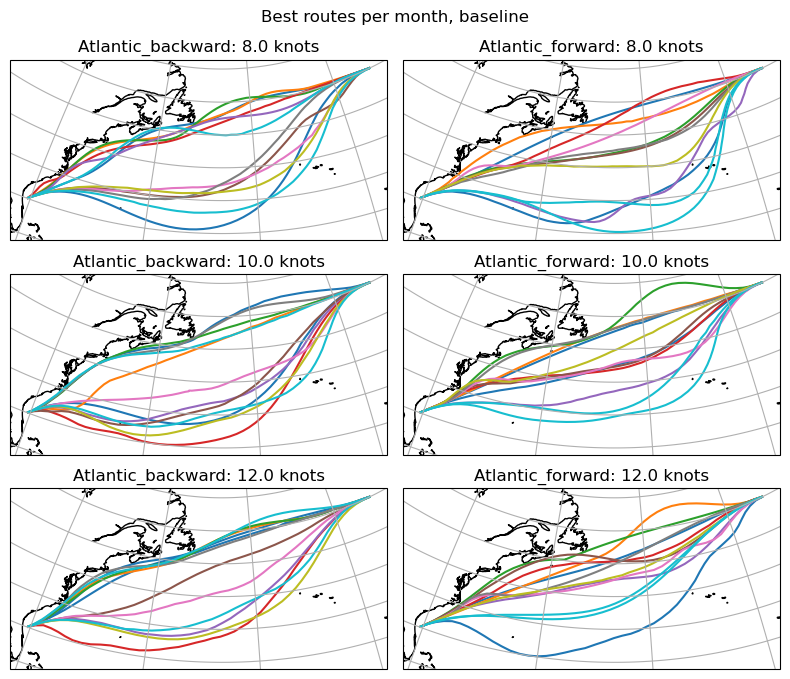

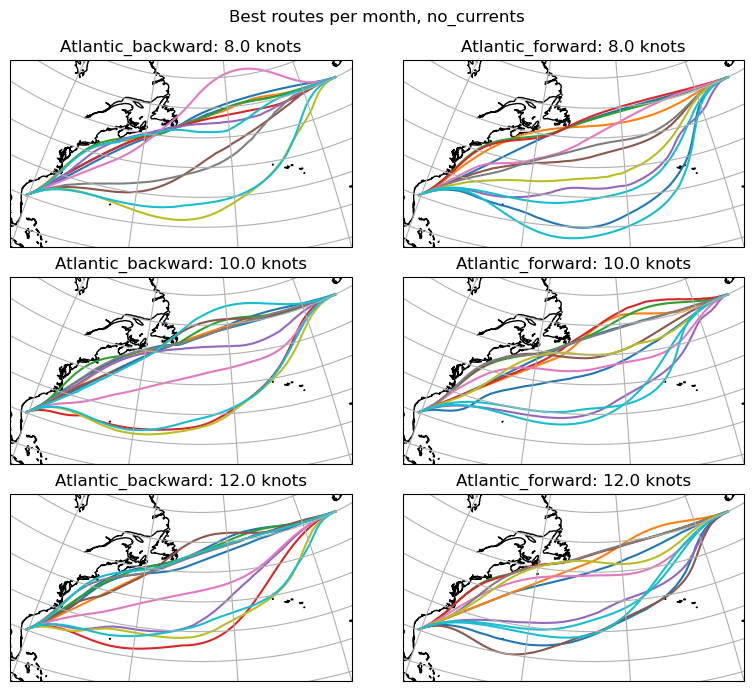

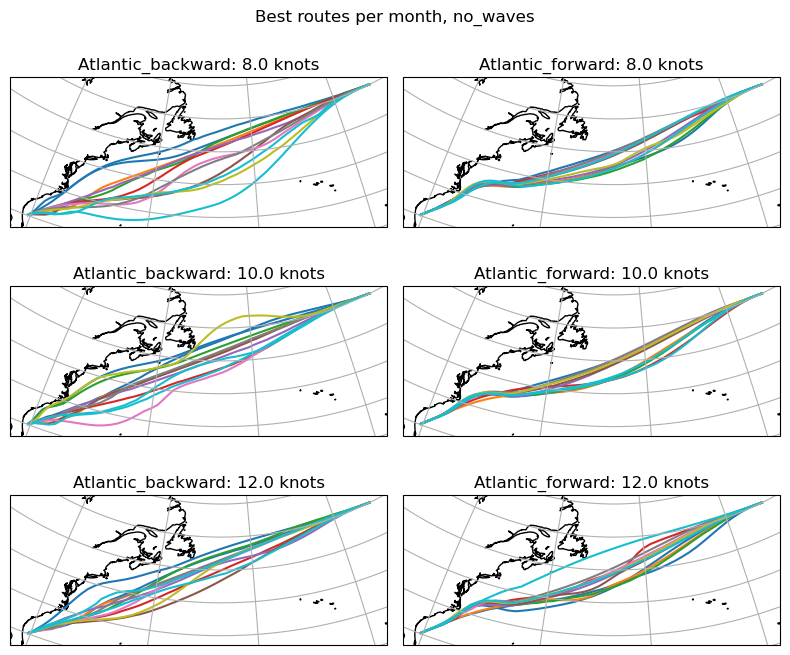

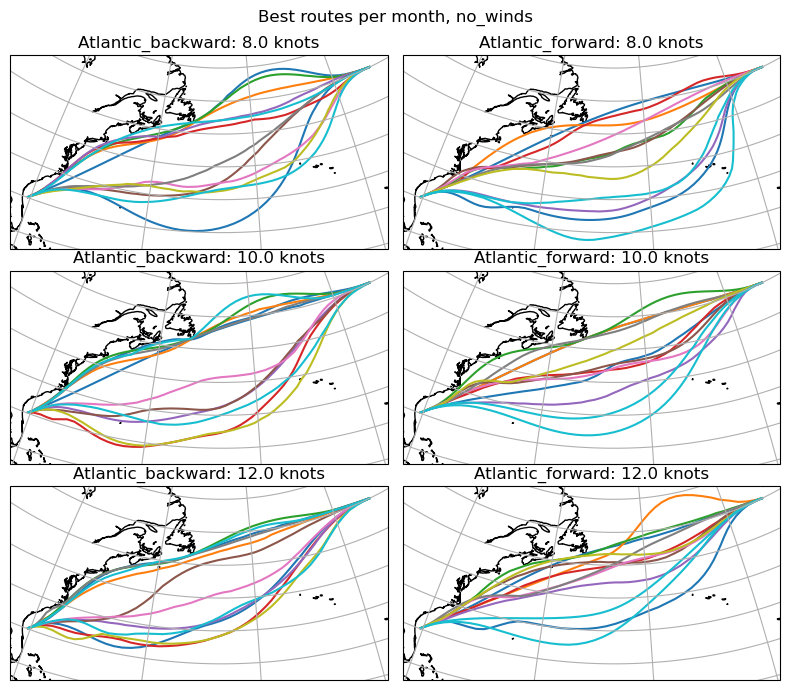

In [9]:
for fsn in gdf.forcing_scenario_name.unique():
    plot_routes_per_month(gdf=gdf, forcing_scenario_name=fsn, hyper_hazard_penalty_multiplier=0);